## Assignment 1 - Classification


## Learning Outcomes


* Data exploration and pre-processing

* Develop a pipeline to carry out classification

* Compare different metrics and classifiers

The objective is to predict whether or not a credit card client will default for their payment in the next month. We will be using the better of 2 classifiers namely, Random Forest and KNN Classifier, and determine the best of a given set of hyperparameters by using grid search.


In [1]:
# Use this for consistency in graphs through out the notebook

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# to make this notebook's output stable across runs

np.random.seed(123)

# To plot pretty figures

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


**Questions (12 marks total)**

Q1.  Explore the credit card data set provided. You can also access it from the this link 

https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients
(https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients)

The data is open for public use and no authorizations are required.

You will build a classification model for this default of credit card clients dataset.  The objective is to predict whether or not a credit card client will default for their payment in the next month.

Make sure you perform your analyses and answer the questions in sections below:

1. Data exploration:  ( 3 marks) 

    - Explore the data ( for example look at the data, plot graphs ( histogram, pair plots)
    
2. Data Preprocessing: (4 marks)

    - Make sure you build a full data pipeline ( ie., use the pipeline to apply transformers and estimators- https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html )
    - Do you require any data pre-processing? Are all the features useful? (Use only raw features from this dataset, in other words, no need to create feature crosses or new features)
    - Set the random seed to 123 (For splitting or any other random algorithm)
    - Split data into training (80%) and testing (20%)
    - Use Cross-validation with 5-folds
    - For other parameters, use default

3. Classification: (5 marks)

    - Study the ROC Curve, decide threshold
    - Use 2 classifiers.
    
         a. Random Forest
            - tune only: n_estimators: {4, 5, 10, 20, 50}.  We will be running random forest model using GridSearchCV, determine the best hyperparameter for the given list of n_estimators {4, 5, 10, 20, 50}. n_estimators refers to the number of trees in the forest. We will use CV = 5 and the scoring to be the roc_auc (area under the curve)
          
       b. KNN Classfier 
            - tune only: n_neighbors: {3, 5, 10, 20}. You may perform similar GridSearchCV as in the previous exercise with a given list of n_neightbors. 
        
    - Which one performs better in the cross validation? Note down your observations and give comments.
    
You may refer to the documentation for RandomForests and KNN Classifiers, for the different parameters and options available in the scikit-learn library.
http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html



### Set the Assignment Goal

The goal of this assignment is to explore a dataset, create a machine learning pipeline and compare classifiers to see which one performs better.

## Import the Data

In [2]:
# Import the data into a DataFrame.

df = pd.read_excel("./default of credit card clients.xls", sheet_name = 0, skiprows= 1, header = 0)


### Exploratory Data Analysis

In [3]:
# Let's see how many rows and columns there are.

df.shape


(30000, 25)

There are 30,000 rows with 25 columns - looks good!

In [4]:
# Let's take a quick look to see what the data looks like.

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# Let's take a look at the columns.

df.dtypes


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

They are all integers.  Therefore, it should align well with supervised machine learning.

In [6]:
# Examine the table in more detail.

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [7]:
# It looks like from above that there are no missing data (e.g., each field is non-null and is
# filled.  However, let's confirm.

df.isnull().sum()


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There are no empty fields which is good news - no imputation or record purging required.


In [8]:
# Define the independent data sub-sets.  Divide them into 4 categories.

profile_list     = [ "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE" ]
pay_status_list  = [ "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6" ]
bill_amt_list    = [ "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6" ]
pay_amt_list     = [ "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6" ]


In [9]:
# Examine the basic statistical information for the LIMIT_BAL and AGE features.

df.loc[:, ["LIMIT_BAL", "AGE"]].describe()


,LIMIT_BAL,AGE
count,30000.000000,30000.000000
mean,167484.322667,35.485500
std,129747.661567,9.217904
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,1000000.000000,79.000000


The median limit balance is $140,000 TWD (~$6.3K CDN) with a range of $10,000 ($422 CDN) to
$1,000,000 TWD ($42,201 CDN).  The median age is 34 with an age range of 21 to 79.

In [10]:
# According to the documentation, there are only two values for the SEX feature.

df["SEX"].value_counts()


2    18112
1    11888
Name: SEX, dtype: int64

Confirmed - there are only two values for the SEX feature - male (1) and female (2).

In [11]:
# Determine how many levels of education are represented.

df["EDUCATION"].value_counts()


2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: EDUCATION, dtype: int64

Most are either University (2) or Graduate School (1) graduates.

In [12]:
# Determine how many different values for MARRIAGE exist.

df["MARRIAGE"].value_counts()


2    15964
1    13659
3      323
0       54
Name: MARRIAGE, dtype: int64

Most people in the data set are single (2) or married (1).  There are 323 'others' and 54 curious '0'.  These 54 could be imputed as 'Other' but on a data set this large, it likely won't make a difference.

In [13]:
# Determine how many different values for PAY_0 exist.  We'll use PAY_0 as an example.

df["PAY_0"].value_counts()

 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: PAY_0, dtype: int64

As there are only a small number of values, we can use classification for the PAY_X fields and we'll use One Hot Encoding for it later on.

In [14]:
# Run some basic statistics on the other feature lists.

df.loc[:, pay_status_list].describe()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100
std,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


The min (-2) and max (8) are the same for all of these features so there doesn't appear to be any outlier data. 

In [15]:
df.loc[:, bill_amt_list].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [16]:
df.loc[:, pay_amt_list].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [17]:
df["PAY_AMT1"].value_counts()


0        5249
2000     1363
3000      891
5000      698
1500      507
         ... 
3391        1
7785        1
66022       1
10121       1
85900       1
Name: PAY_AMT1, Length: 7943, dtype: int64

It looks like the BILL_AMT and PAY_AMT scales are quite different.  Therefore, these are candidates for feature scaling during the Pipeline Pre-processing.

### Dependent (Target) Variable

There is one dependent variable and that is "default payment next month" which is either 1 for yes, or 0 for no.

In [18]:
# Take a look to see how many of these 30K people will not default ('0') and how many will ('1').

df['default payment next month'].value_counts()


0    23364
1     6636
Name: default payment next month, dtype: int64

Good!  There is nothing other than what was expected (0 and 1).

In [19]:
# Take a look at the Target, default payment next month, and see if it's a balanced dataset.

df["default payment next month"].value_counts(normalize = True) * 100

0    77.88
1    22.12
Name: default payment next month, dtype: float64

I believe the ideal is somewhere near a 50-50 or 60-40 split.  This is a bit off at 78-22 but should be ok.

### Independent (Features) Variables

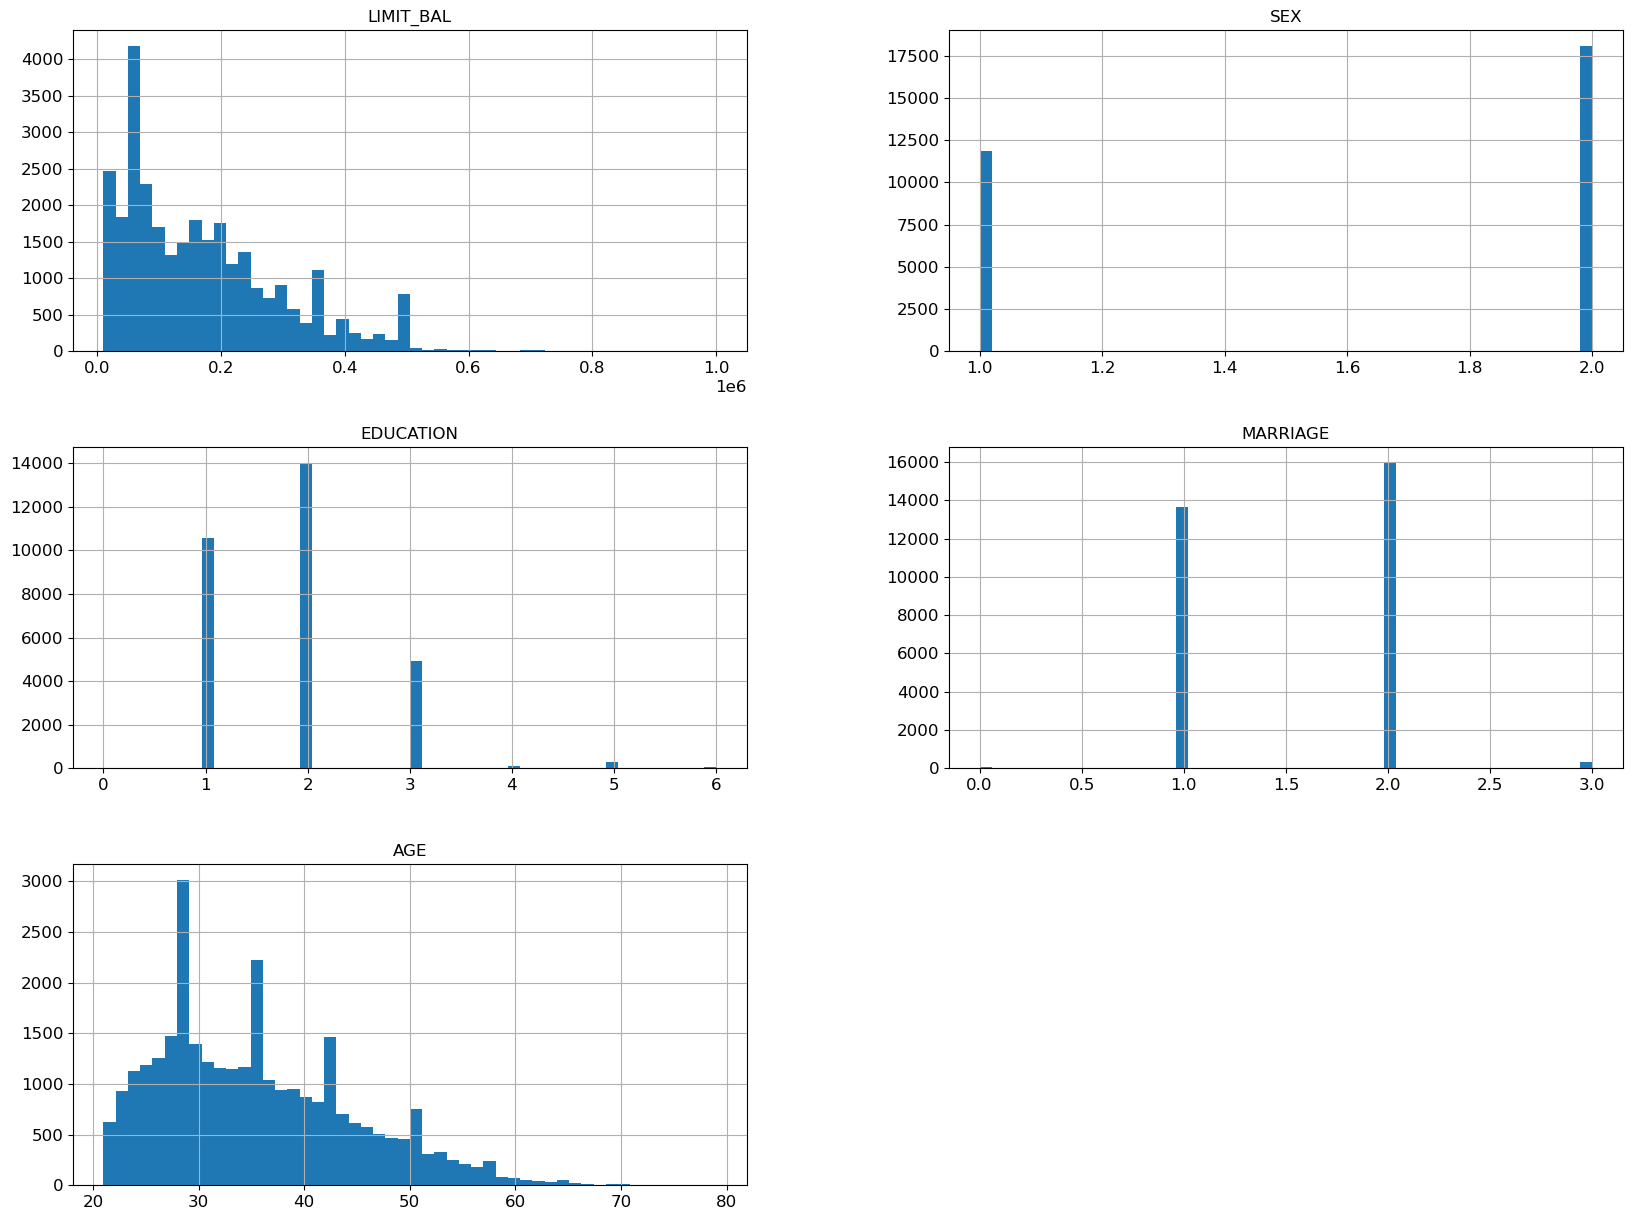

In [20]:
# Let's look at the distribution of features in the client profile list.

df.loc[:, profile_list].hist(bins=50, figsize=(20,15))
plt.show()


The Limit Balance skews right which makes sense as most people would have smaller credit Limit Balances.  The Age also skews right as more people in their 20's and 30's will carry debt.

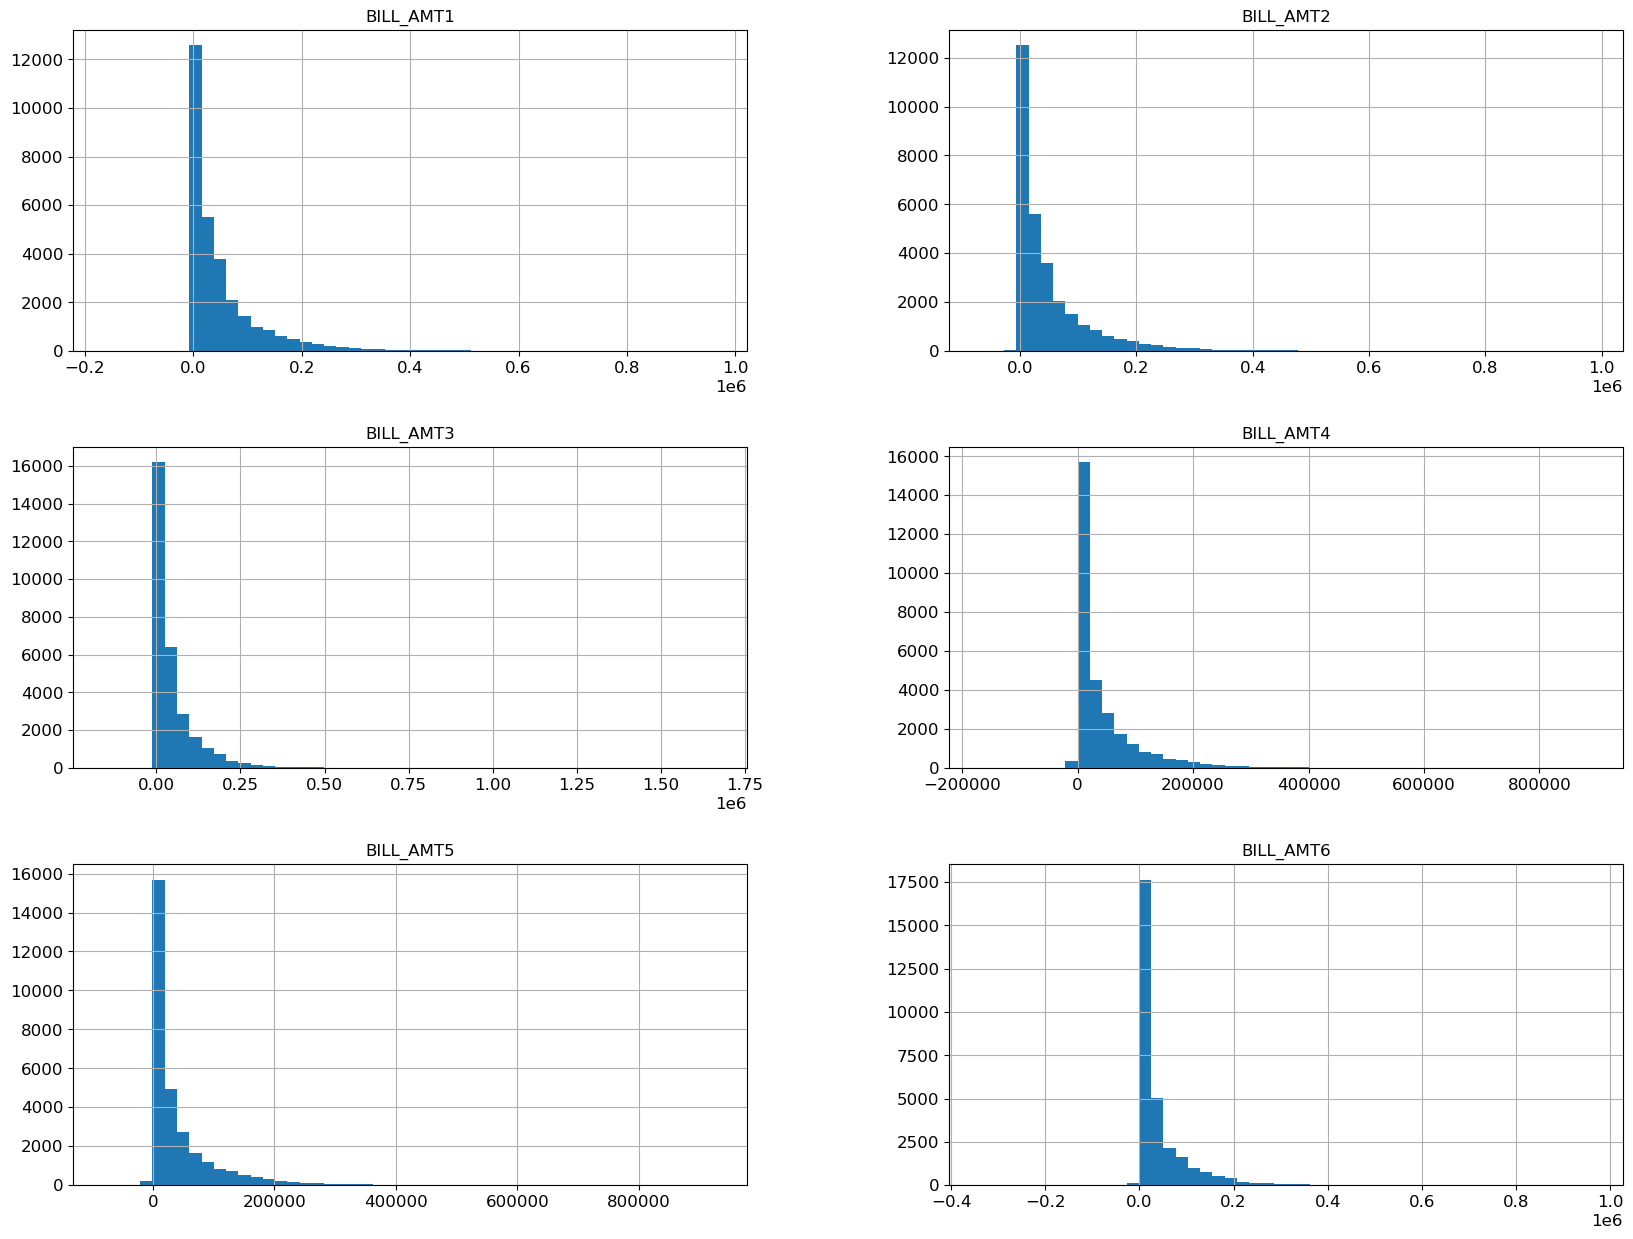

In [21]:
# Let's look at the distribution of the Bill Statement Amounts.

df.loc[:, bill_amt_list].hist(bins=50, figsize=(20,15))
plt.show()

The data skews right which shows that most people are not spending large amounts of money each month or carrying large balances.

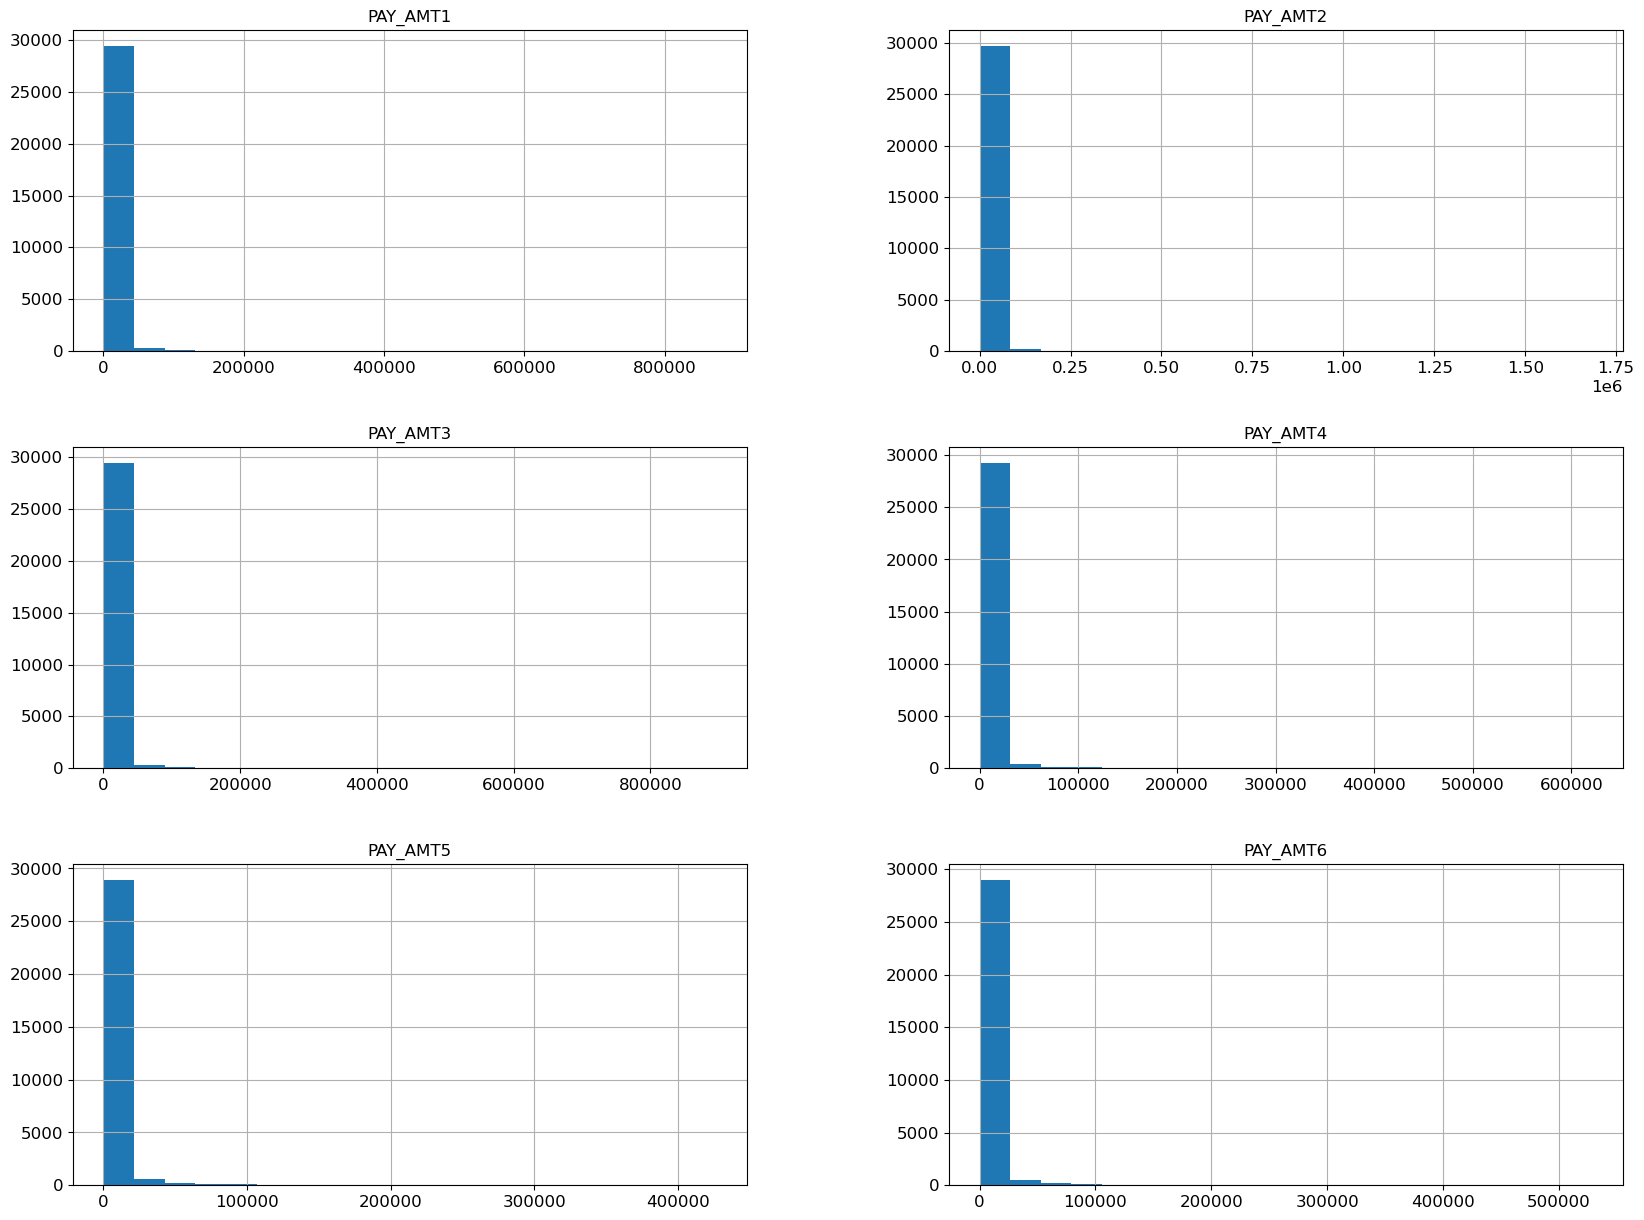

In [22]:
# Let's look at the distribution for past payment amounts,

df.loc[:, pay_amt_list].hist(bins=20, figsize=(20,15))
plt.show()


The data skews right which shows that most people are not paying large amounts of money each month on their credit card bills.

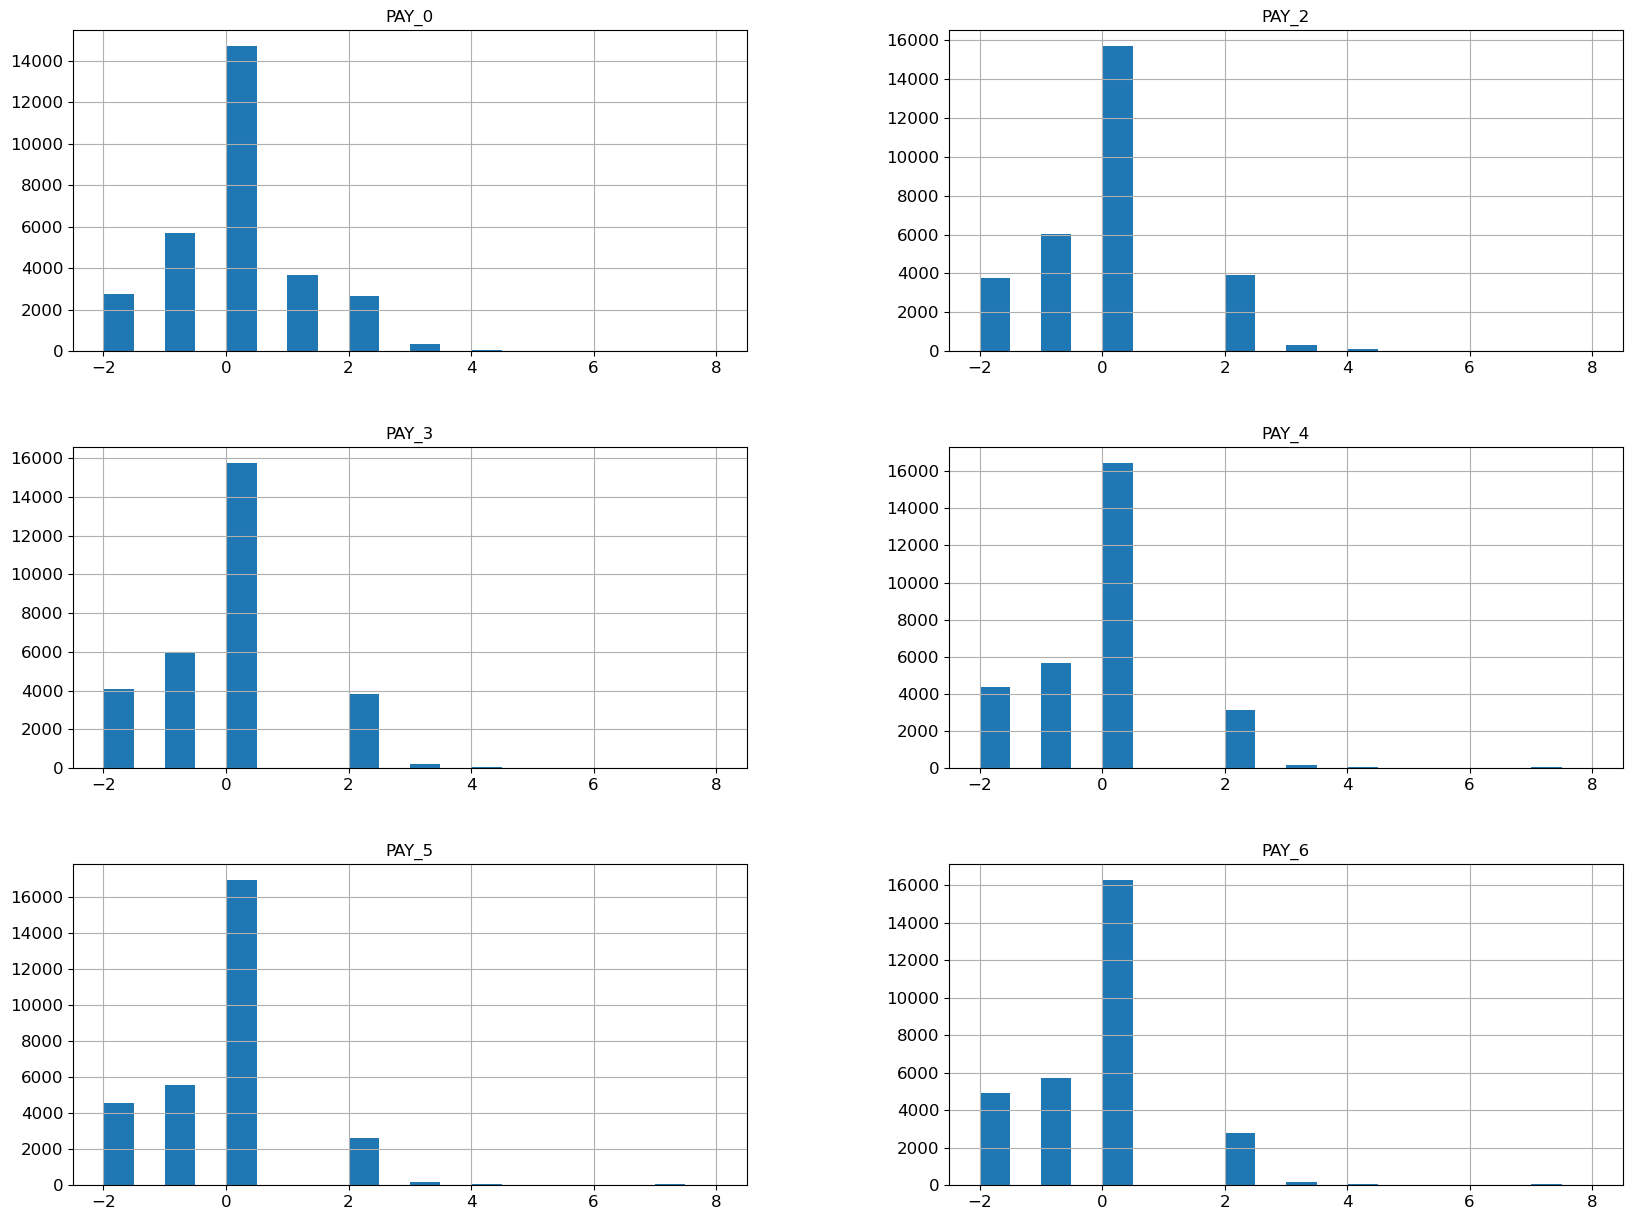

In [23]:
# Let's look at the distribution for history of past payment amounts. 

df.loc[:, pay_status_list].hist(bins=20, figsize=(20,15))
plt.show()

The data leans to be normally distributed centred around 0 as it appears that most people are paying their credit card bills on time.  Not many have payment delays larger than 3 months.

In [24]:
# Create correlation functions.

def create_correlation(target, features):
    my_matrix = df.loc[:, [target] + features].corr(method='pearson')
    return my_matrix[target].sort_values(ascending=False)

def print_correlation_plot(target, features):
    sns.pairplot(data=df.loc[:, [target] + features])
    plt.show()

In [25]:
# Run some correlations on the BILL_AMT set of features and the Default Payment Next Month target.

create_correlation("default payment next month", bill_amt_list)


default payment next month    1.000000
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
Name: default payment next month, dtype: float64

There doesn't appear to be much correlation between the BILL STATEMENT AMOUNTS and whether or not they will default on their credit card next month.

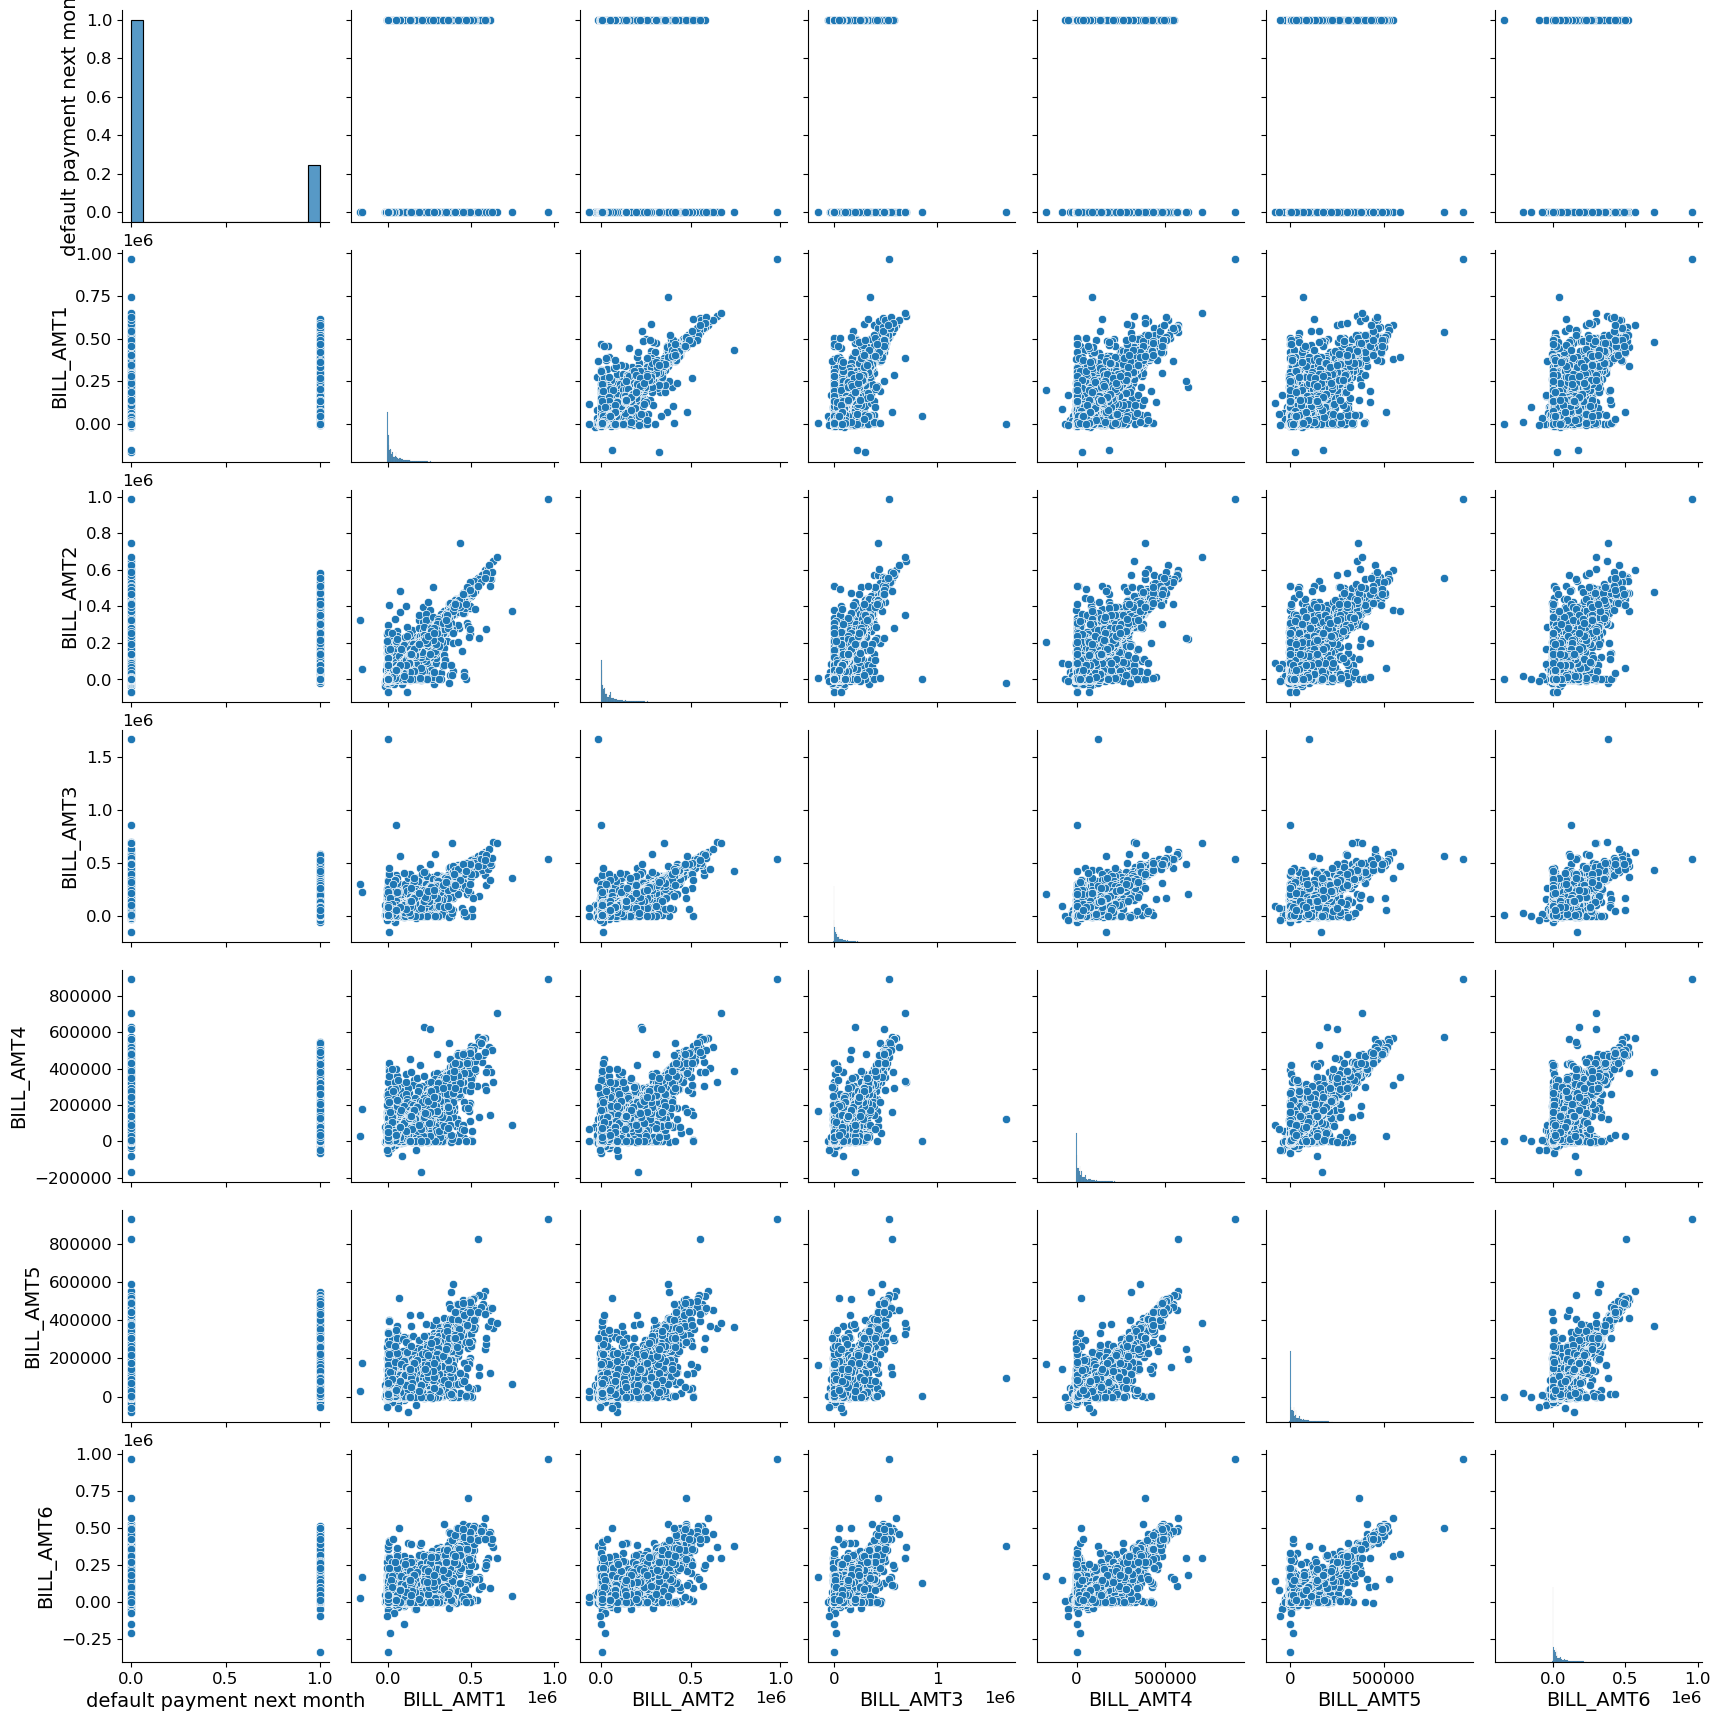

In [26]:
# Print the plot.

print_correlation_plot("default payment next month", bill_amt_list)


This seems to confirm it.  There seems to be a lot of correlation between the bill amounts, not so much when tied to the default payment next month.

In [27]:
# Run some correlations on the PAY_AMT set of features and the Default Payment Next Month target.

create_correlation("default payment next month", pay_amt_list)


default payment next month    1.000000
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
Name: default payment next month, dtype: float64

There doesn't appear to be any correlation between the PAYMENT AMOUNTS or when tied to whether or not they will default on their credit card next month.

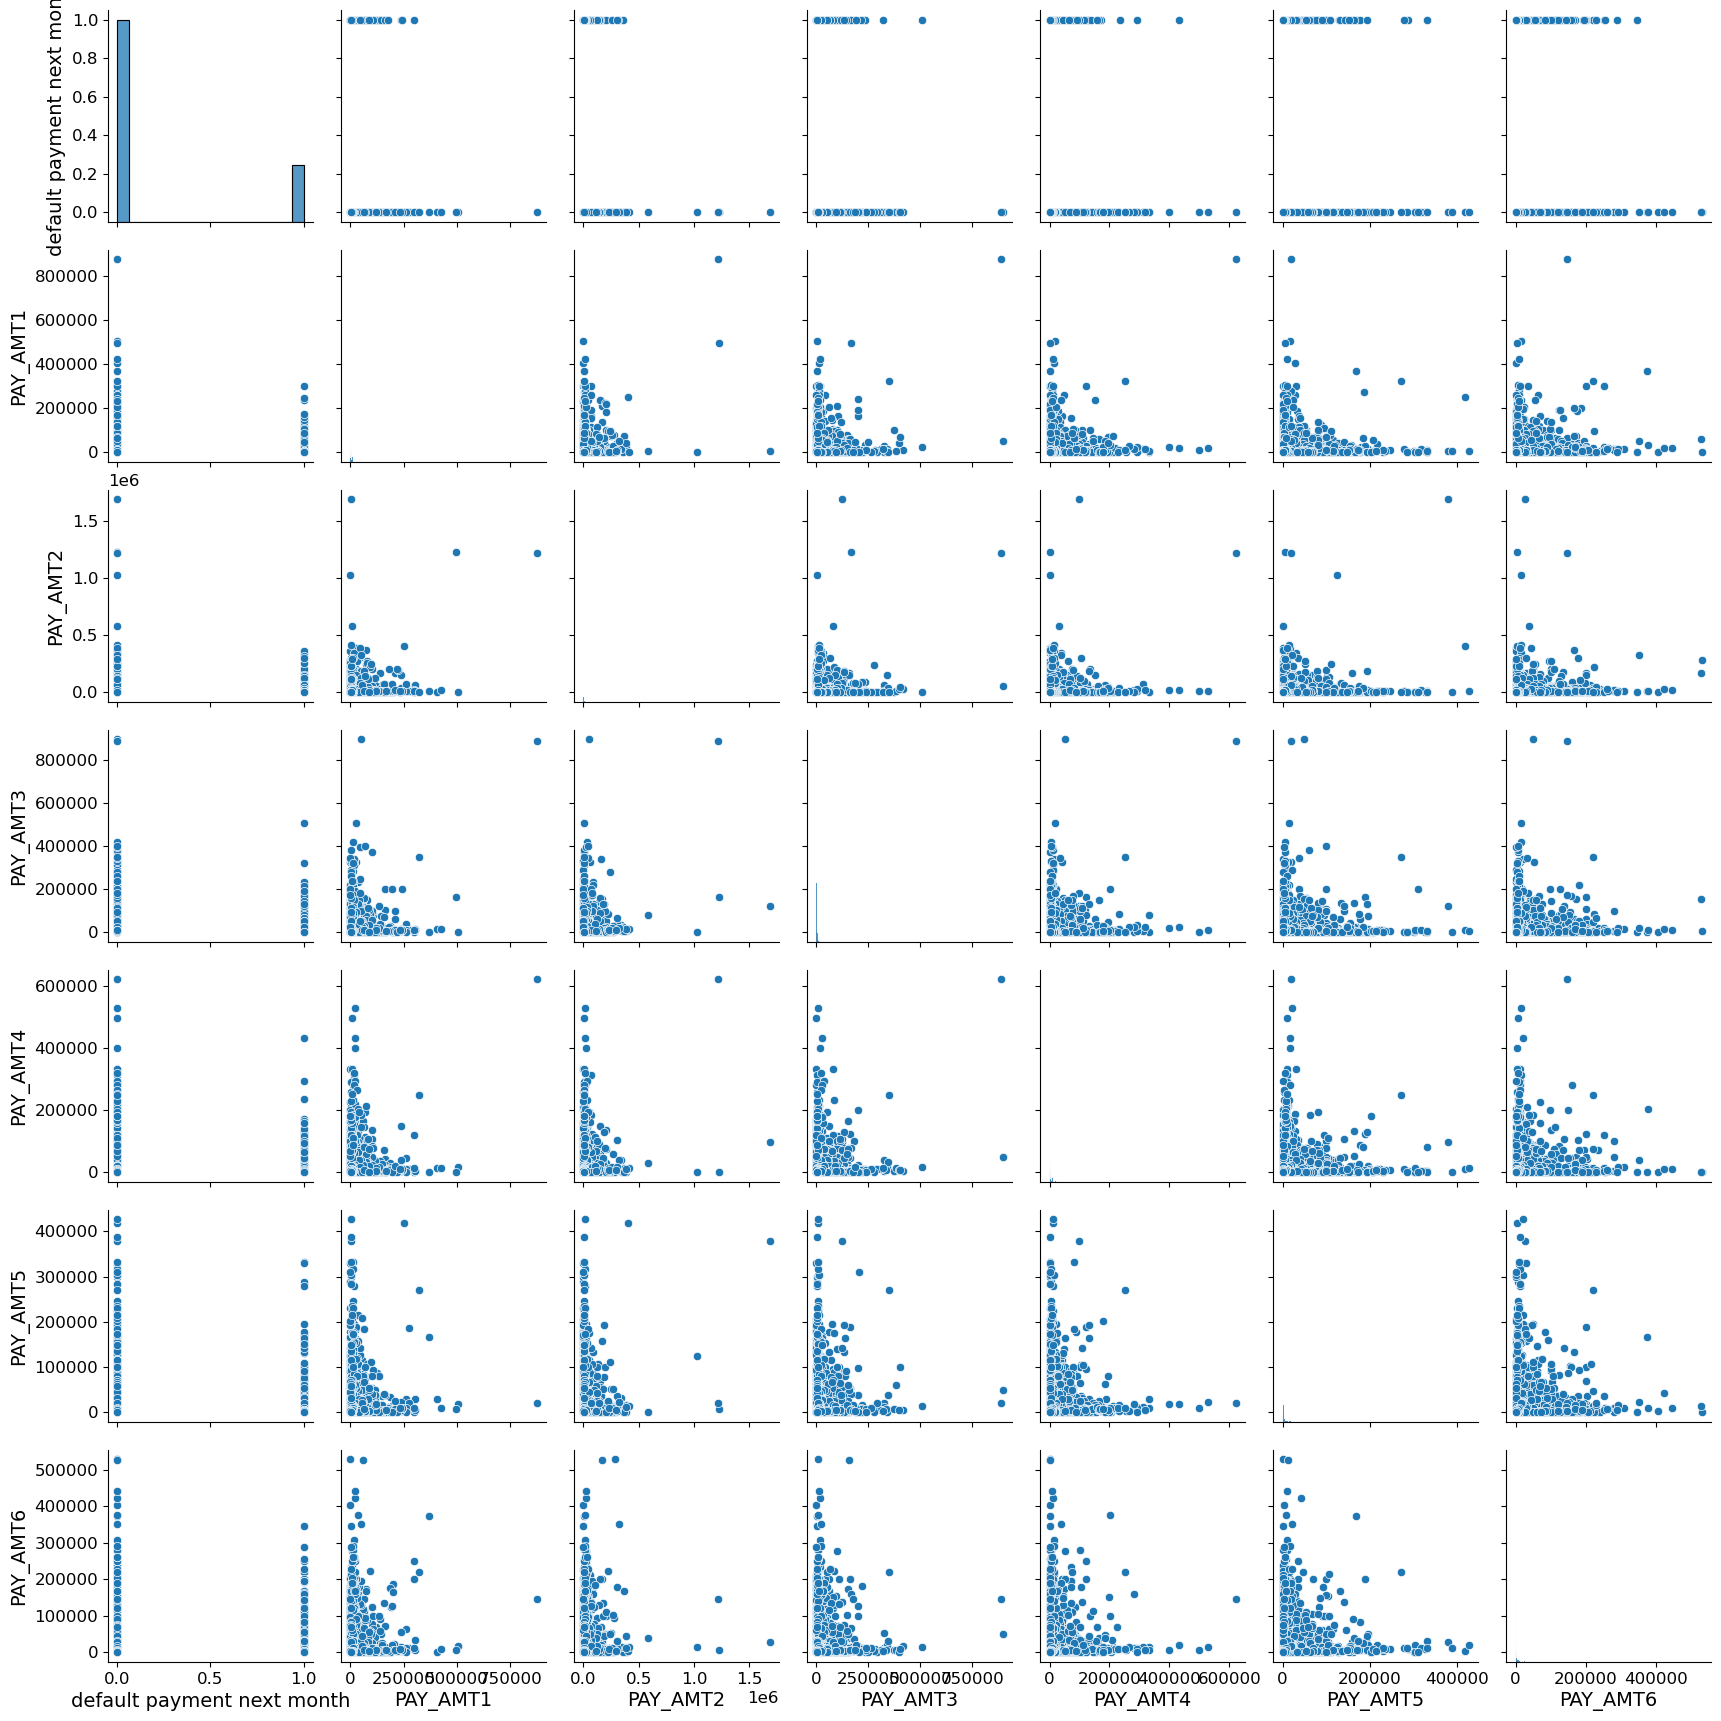

In [28]:
# Print the plot.

print_correlation_plot("default payment next month", pay_amt_list)


This seems to confirm it.  There doesn't seem to be any correlation between the payment amounts or when tied to the default payment next month.

In [29]:
# Run some correlations on the PAY_X set of features and the Default Payment Next Month target.

create_correlation("default payment next month", pay_status_list)


default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
Name: default payment next month, dtype: float64

PAY_0, which is the last payment seems to have a stronger correlation as to whether or not the person will default on their payment.

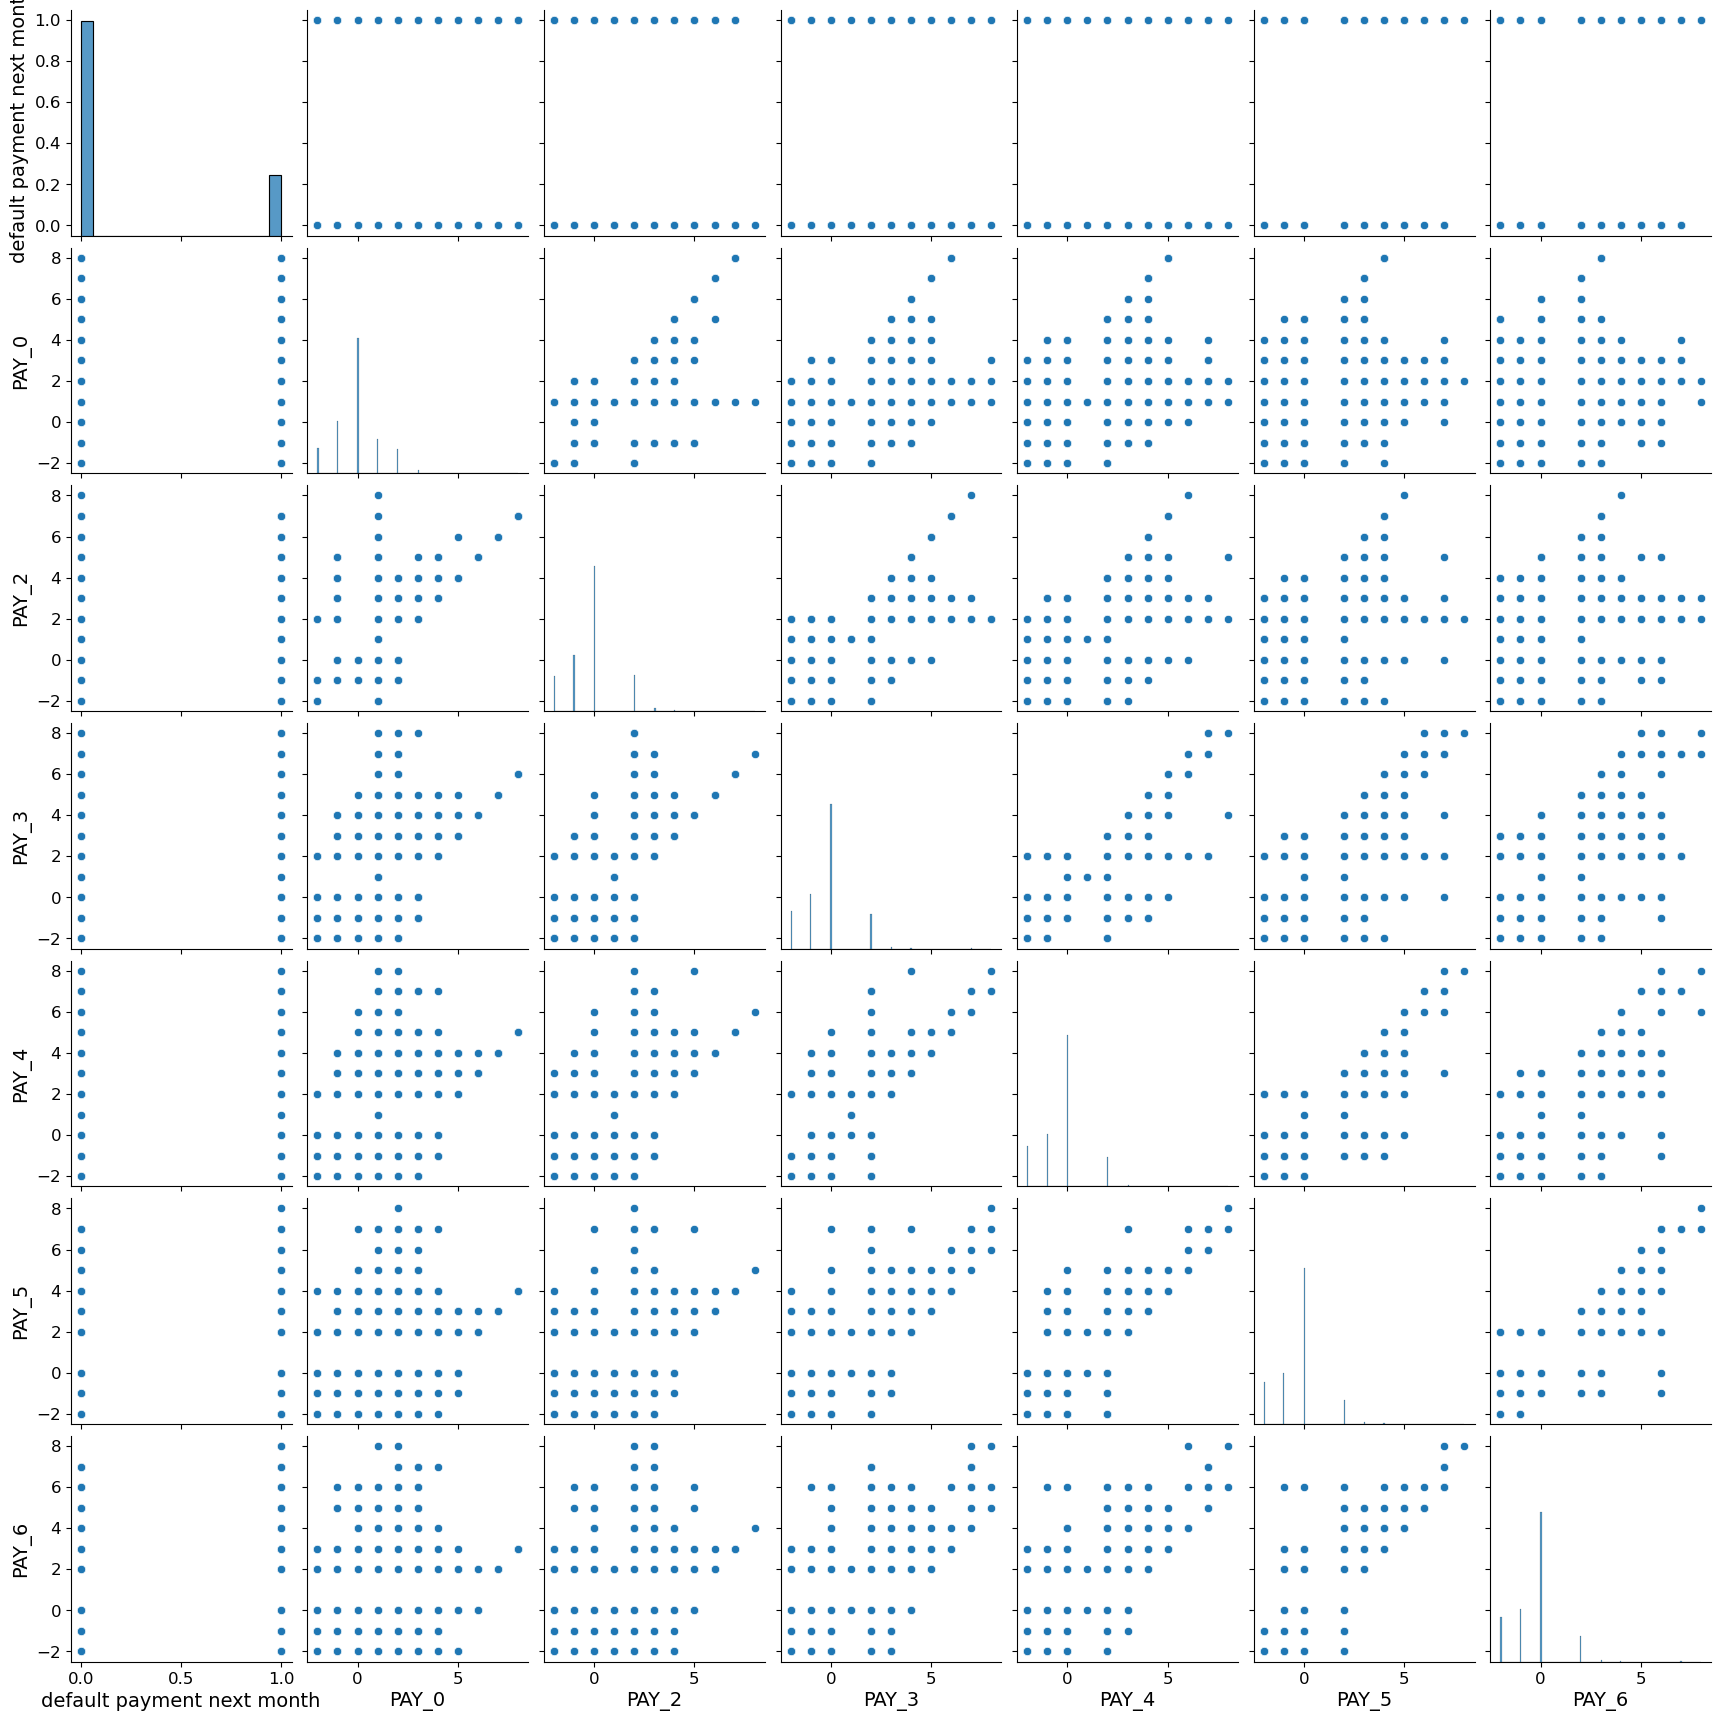

In [30]:
# Print the plot.

print_correlation_plot("default payment next month", pay_status_list)


In [31]:
# Create a box plot function using the function in the course notes.

def create_box_plot(x_axis, y_axis):
    plt.figure(figsize=(5,5))
    sns.boxplot(x=x_axis, y=y_axis, data=df)
    
    if len(df[x_axis].unique()) > 4:
        plt.xticks(rotation=45)
        
    plt.show()

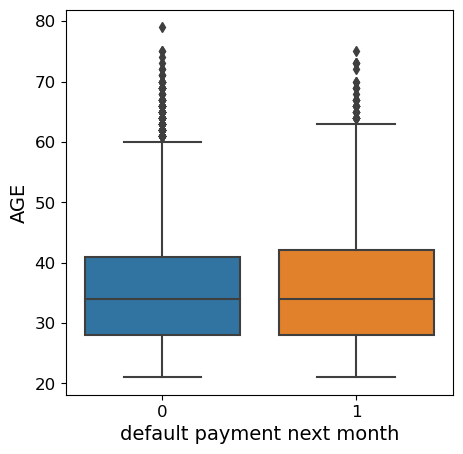

In [32]:
# Boxplot Age vs Default Payment Next Month.

create_box_plot('default payment next month', 'AGE')


Age does not appear to be a factor.

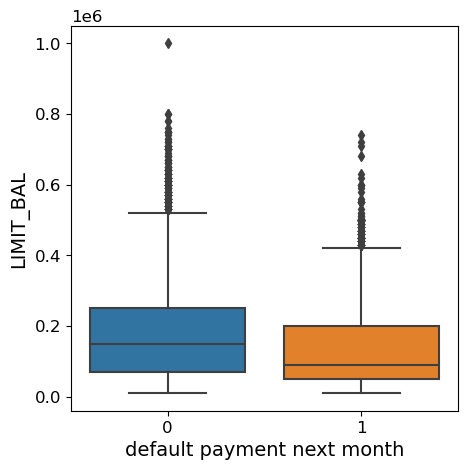

In [33]:
# Boxplot LIMIT_BAL vs Default Payment Next Month.

create_box_plot('default payment next month', 'LIMIT_BAL')


Limit Balance may be a slight factor.

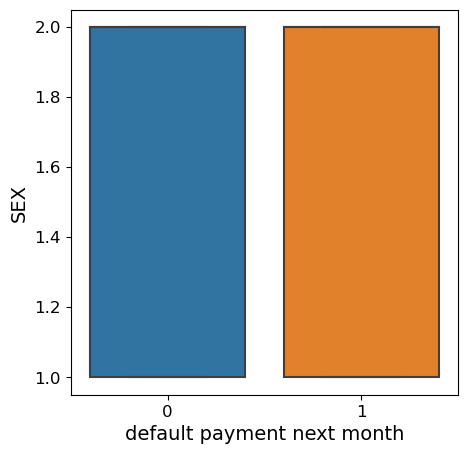

In [34]:
# Boxplot LIMIT_BAL vs Default Payment Next Month.

create_box_plot('default payment next month', 'SEX')


The payee's sex does not seem to be a factor.

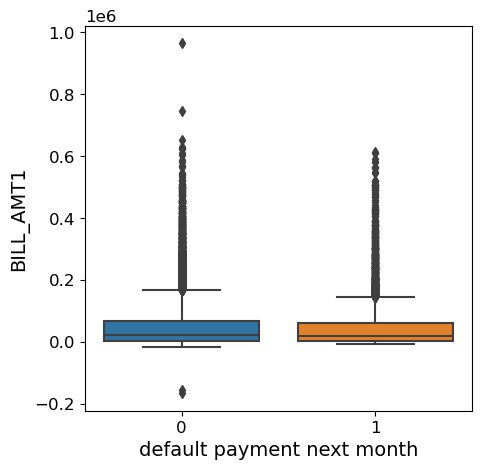

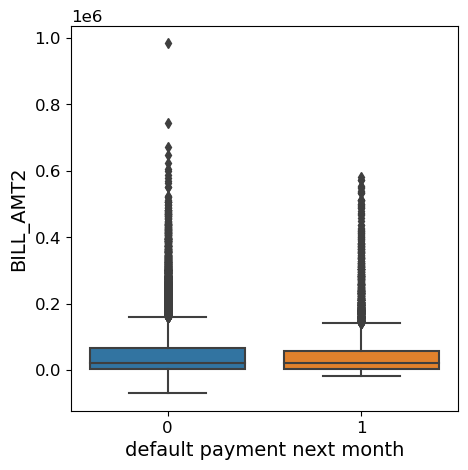

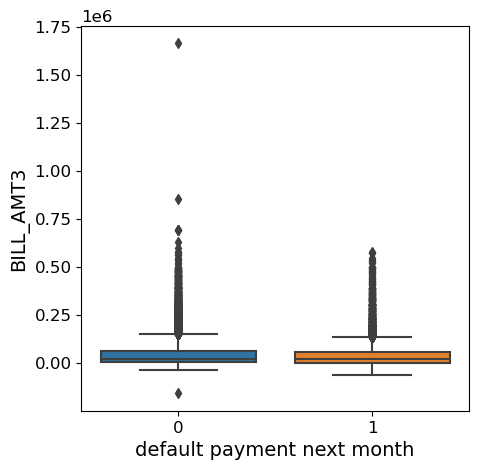

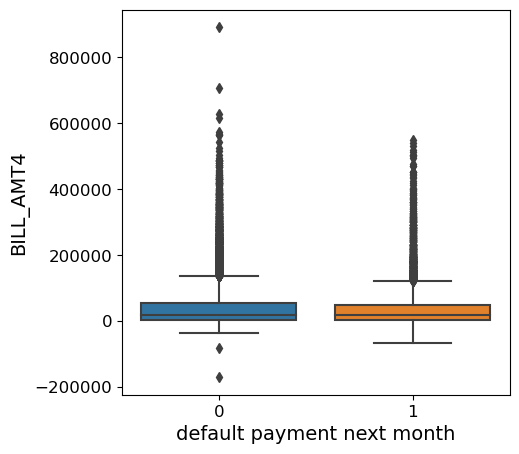

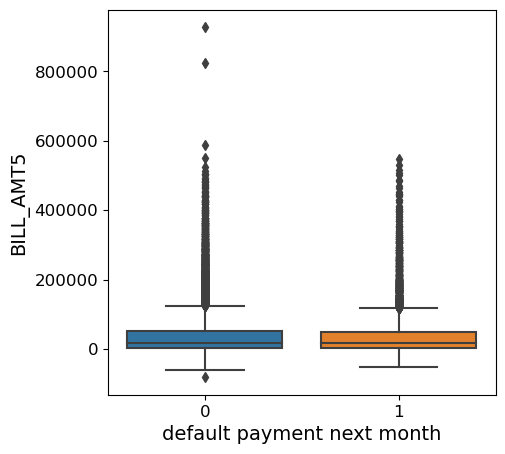

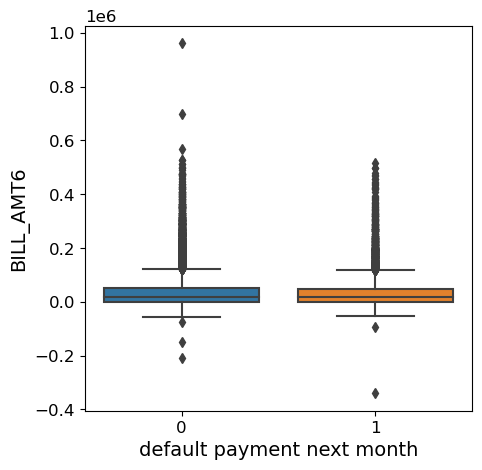

In [35]:
for i in bill_amt_list:
    create_box_plot('default payment next month', i)

There doesn't appear to be a correlation between the PAY STATEMENT and the target.  This may verify what we say before.

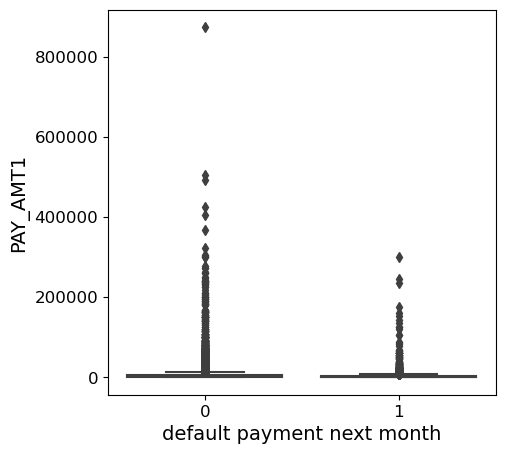

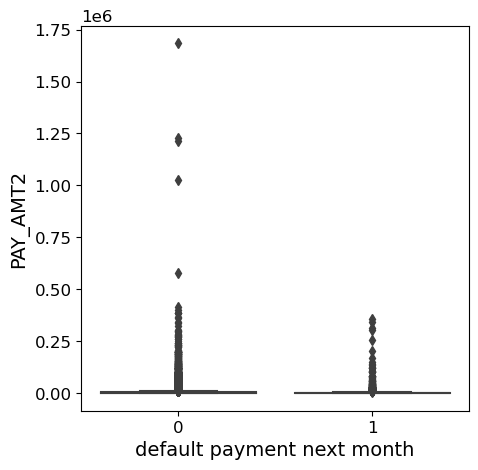

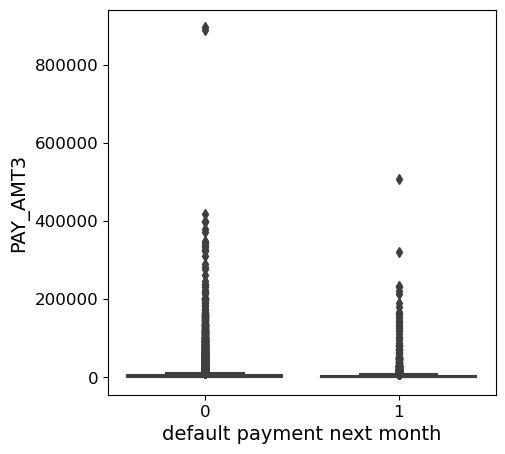

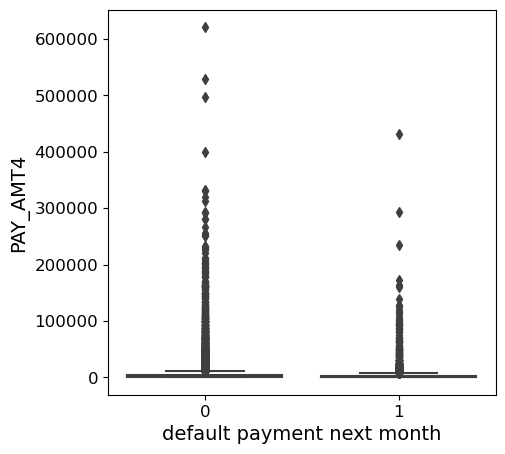

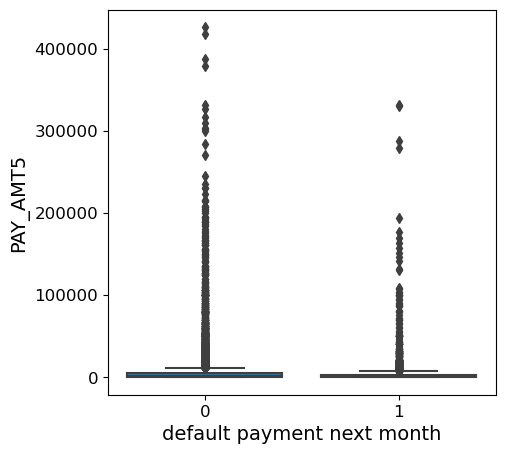

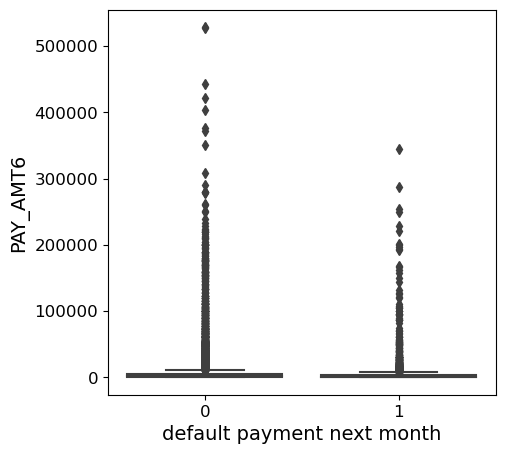

In [36]:
for i in pay_amt_list:
    create_box_plot('default payment next month', i)

There doesn't appear to be a correlation between the PAY_AMTs and the target.  

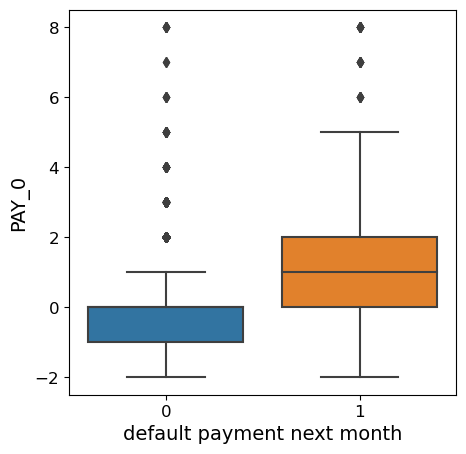

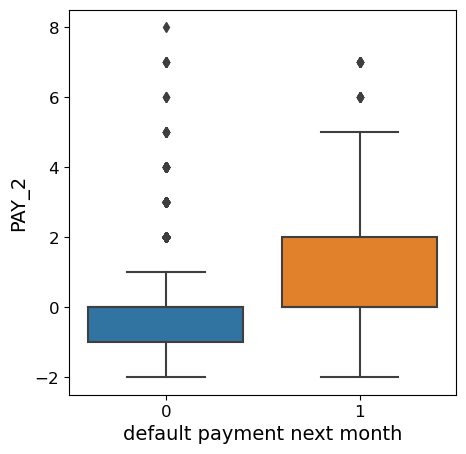

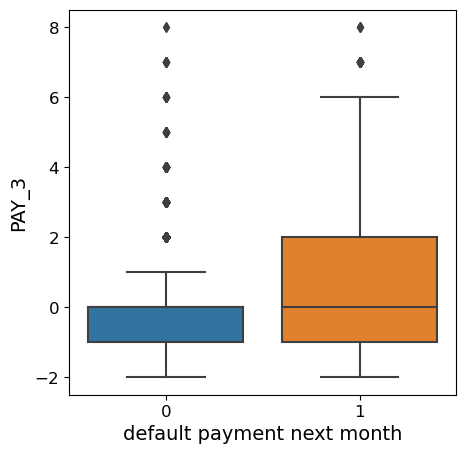

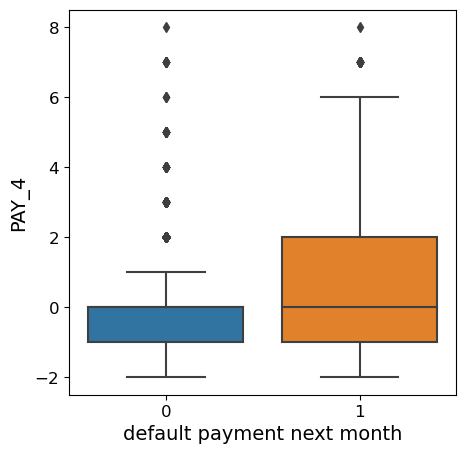

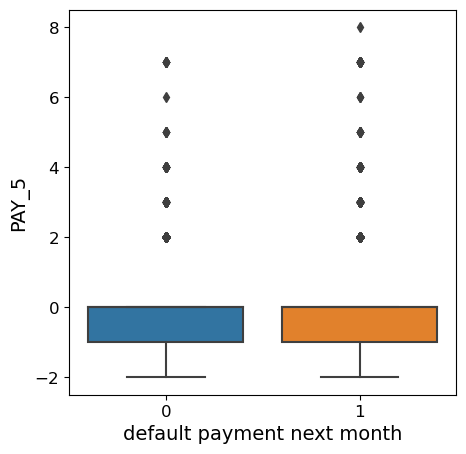

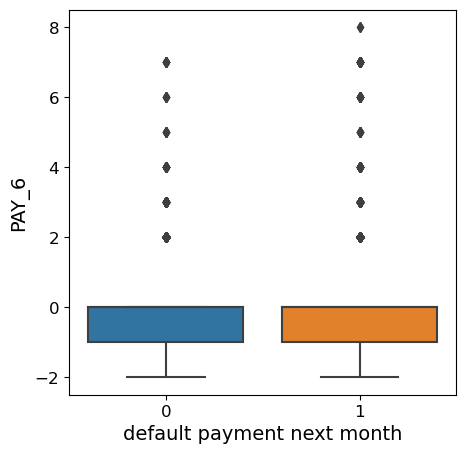

In [37]:
for i in pay_status_list:
    create_box_plot('default payment next month', i)


Apart from PAY_5 and PAY_6, there looks to be a correlation between the PAY and the target.  

Therefore, the PAY_X features may be the largest factor as they seem to have the biggest correlation on default payment.

### PIPELINES

Create the machine learning pipeline to include transformations (e.g., One Hot Encoding, MinMax Scaler).

#### Imputation

There are no missing values in the data set so no imputation is required.

In [38]:
# Define the model's categorical and numerical features.  Note that PAY_0 etc. are also
# categorical features.

categorical_features = [ "SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6" ]

numerical_features = [ "LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
                       "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6" ]

In [39]:
# Categorical

# Use One Hot Encoding on the features that, even though they are integers, are essentially
# categories.

cat_ohe_step = ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
cat_steps = [cat_ohe_step]
cat_pipe = Pipeline(cat_steps)

cat_transformers = [('cat', cat_pipe, categorical_features)]

# Numerical

# To ensure those features with large values don't have more influence than those numerical
# features that have smaller values.

num_scl_step = ('scl', MinMaxScaler(feature_range=(0,1)))
num_steps = [num_scl_step]
num_pipe = Pipeline(num_steps)
num_transformers = [('num', num_pipe, numerical_features)]

In [40]:
# Create the Column Transformer with the categorical and numerical transformers.

ct = ColumnTransformer(transformers=cat_transformers + num_transformers)

ct.fit(df[categorical_features + numerical_features])

# Set the features, X.

X = ct.transform(df[categorical_features + numerical_features])

# Set the target, y.

y = df[['default payment next month']].values

In [41]:
# Now, implement the Train-Test Split using our X and y variables.  Aim for a 20-30% test size.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(24000, 91) (6000, 91) (24000, 1) (6000, 1)


In [42]:
# Let's take a quick look at the training data.

print(X_train)

[[1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 4.16141761e-01]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.66183575e-03
  4.15047980e-02 9.29509369e-03]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.15942029e-02
  8.44022329e-03 7.37705848e-03]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 3.22061192e-03
  4.68901294e-03 3.78310691e-03]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 2.81964573e-03
  4.07006323e-03 5.61980532e-03]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.80193237e-04
  4.14977645e-04 3.42371176e-04]]


In [43]:
# Calculate RMSE method from the course documentation.

def rmse(a, b):
    return np.sqrt(np.mean((a-b)**2))

In [44]:
# Display results for model from the course documentation.

def display_results(model, X, y):
    print("RMSE:", rmse(model.predict(X), y))
    print("Predicted 1-5:", model.predict(X_test[0:5]))
    print("Actual 1-5:", y_test[0:5, 0])
    

In [45]:
# Display the scores from the course documentation.

def display_scores(scores):
    print("Scores:", np.sqrt(-scores))
    print("Mean:", np.sqrt(-scores).mean())
    print("Standard deviation:", np.sqrt(-scores).std())


#### RandomForestClassifier

As this is a classification problem as opposed to a regression problem, initialize the Randdom Forest Classifier.

In [46]:
# Create the RandomForestClassifier and fit the training data.

rfc = RandomForestClassifier(n_estimators=10)
rfc.fit(X_train, np.ravel(y_train))

display_results(rfc, X, y)

RMSE: 0.5691961583379377
Predicted 1-5: [0 0 0 0 0]
Actual 1-5: [0 0 0 0 1]


The RMSE is not bad - 0.57 and the predicted and actual values are pretty good.

**Cross-Validate Random Forest Classifier**

In [47]:
# Now, put it through cross validation to see if the scores are better.

enr = RandomForestClassifier()
scores = cross_val_score(enr, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [0.4425306  0.43627209 0.42465672 0.4151305  0.42544095]
Mean: 0.42880617226783946
Standard deviation: 0.009588185003985575


The cross-validation with K fold of 5 shows far better scores.

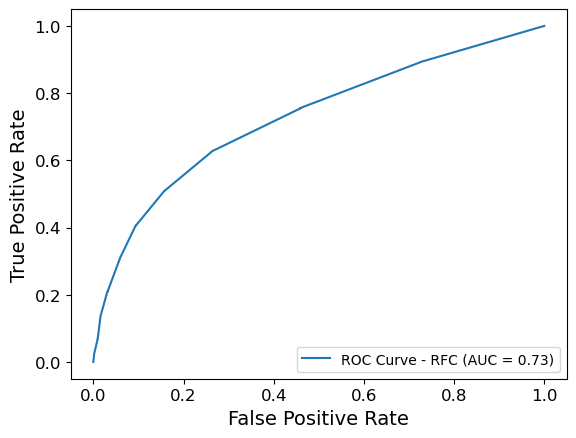

In [48]:
# Now look at the ROC curve and calculate the Area Under Curve (AUC) for this model.

fpr, tpr, thresholds = roc_curve(y_test, rfc.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, rfc.predict_proba(X_test)[:, 1])

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='ROC Curve - RFC')
display.plot()
plt.show()

The AUC for the Random Forest Classifier is 0.73.

#### KNN Classifier

In [49]:
# Create the KNeighborsClassifier with 15 neighbours and fit the training data.

neighbours = 15
knn = KNeighborsClassifier(n_neighbors=neighbours)
knn.fit(X_train, y_train.ravel())
        
display_results(knn, X, y)

RMSE: 0.535529968037893
Predicted 1-5: [0 0 0 0 0]
Actual 1-5: [0 0 0 0 1]


The RMSE is not bad - 0.54 and the predicted and actual values are pretty good.  It is marginally better than the RandomForestClassifier at 0.57.

**Cross-Validate KNN Classifier**

In [50]:
# Now, put it through cross validation to see if the scores are better.

enr = KNeighborsClassifier()
scores = cross_val_score(enr, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [0.45971005 0.46188022 0.45129443 0.43435776 0.4473999 ]
Mean: 0.45092847252051876
Standard deviation: 0.009841036715974085


The cross-validation with K fold of 5 shows far better scores but interestingly, slightly worse than the RandomForestClassifier.

[2.         1.         0.93333333 0.86666667 0.8        0.73333333
 0.66666667 0.6        0.53333333 0.46666667 0.4        0.33333333
 0.26666667 0.2        0.13333333 0.06666667 0.        ]


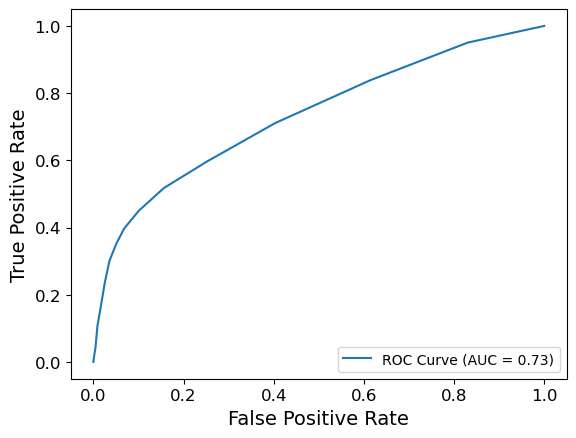

In [51]:
# Now look at the ROC curve and calculate the Area Under Curve (AUC) for this model.

fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])
print (thresholds)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='ROC Curve')
display.plot()
plt.show()

The AUC for the KNN Classifier is 0.73 - the same as the Random Forest Classifier.

### Hyperparameter Search

**RandomForestClassifier**

In [52]:
# Hyperparameter Search for RandomForestClassifier.

estimator = RandomForestClassifier()
param_grid = { 
            "n_estimators"      : [4, 5, 10, 20, 50],  # Add all 5 estimators
            "max_features"      : ["sqrt", "log2"],
            "min_samples_split" : [2,4,8],
            "bootstrap": [True, False],
            }

grid = GridSearchCV(estimator, param_grid, n_jobs=-1, cv=5)

grid.fit(X_train, y_train.ravel())


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [4, 5, 10, 20, 50]})

In [53]:
# Print out the best parmaeters and best estimator.

print(grid.best_params_)
print("\n",grid.best_estimator_)

{'bootstrap': True, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 50}

 RandomForestClassifier(min_samples_split=8, n_estimators=50)


In [54]:
# Calculate the RMSE for the RandomForestClassifier.

final_model = grid.best_estimator_
display_results(final_model, X_test, y_test)

RMSE: 0.5366504655939677
Predicted 1-5: [0 0 0 0 0]
Actual 1-5: [0 0 0 0 1]


The RMSE for the RandomForestClassifier using the best estimator is slightly better (.54) than in the regular case (.57).

In [55]:
# Finally, conduct a cross-validation on this model.

scores = cross_val_score(final_model, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [0.44215382 0.43703547 0.4236744  0.41311822 0.41992063]
Mean: 0.42718050827186166
Standard deviation: 0.010808022603321945


**KNN Classifier**

In [56]:
# Hyperparameter Search for KNN Classifier.

estimator = KNeighborsClassifier()
param_grid = { 
            "n_neighbors"       : [3, 5, 10, 20],
            }

grid = GridSearchCV(estimator, param_grid, n_jobs=-1, cv=5)

grid.fit(X_train, y_train.ravel())


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 10, 20]})

In [57]:
# Print out the best parmaeters and best estimator.

print(grid.best_params_)
print("\n",grid.best_estimator_)

{'n_neighbors': 20}

 KNeighborsClassifier(n_neighbors=20)


In [58]:
# Calculate the RMSE for the KNN Classifier.

final_model_KNN = grid.best_estimator_
display_results(final_model_KNN, X_test, y_test)

RMSE: 0.5276556115919213
Predicted 1-5: [0 0 0 0 0]
Actual 1-5: [0 0 0 0 1]


The RMSE for the KNN Classifier using the best estimator is slightly better (.53) than in the regular case (.54).

In [59]:
# Finally, conduct a cross-validation on this model.

scores = cross_val_score(final_model_KNN, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [0.44497191 0.43608103 0.42563678 0.4173328  0.42091171]
Mean: 0.42898684580710783
Standard deviation: 0.010179364312276435


#### Conclusions

For this machine learning model, supervised learning is selected as there is a target for ability to pay off their credit card.

Classification models were used (as opposed to regression) as the target, default payment, is either true or false, 1 or 0.

The models seem to perform just as well as each other.  The models perform better when cross-validation is used and in particular, when cross-validation is performed on the hyperparameter search